In [4]:
%load_ext autoreload
%autoreload 2

import sys
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

PYGENELAB_PARENT = Path("/ix/djishnu/Akanksha/analysis_code/snRNA_TA_muscle_analysis/TA_muscle_code/py_scripts")
if str(PYGENELAB_PARENT) not in sys.path:
    sys.path.insert(0, str(PYGENELAB_PARENT))

import pygenelab as pgl
import pandas as pd
import matplotlib.pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
SEX_CONDITION_PALETTE = {
    ('M', 'WT'): '#004a99',  # Control male
    ('M', 'KO'): '#90bff9',  # SkM-KO male
    ('F', 'WT'): '#f71480',  # Control female
    ('F', 'KO'): '#fa98c7',  # SkM-KO female
}

# Sex-only collapse (used when a plot isn't split by condition — picks WT shade).
SEX_PALETTE = {
    'F': SEX_CONDITION_PALETTE[('F', 'WT')],
    'M': SEX_CONDITION_PALETTE[('M', 'WT')],
}

# Make sure SVG text stays editable in Illustrator (text elements, not paths).
import matplotlib.pyplot as plt
plt.rcParams.update({
    "text.usetex": False,
    "svg.fonttype": "none",
})
figure_params = {
    "dpi": 300,
    "bbox_inches": "tight",
    "format": "svg",
    "transparent": True,
}

figures_dir = '/ix/djishnu/Akanksha/datasets/ERCC1_KO/figures'

## Females (Z12 and Z15) 

In [6]:
Z12_file = '/ix/djishnu/Akanksha/datasets/ERCC1_KO/metacell/slide_outs/optimize_slide/female_0.1_spec/0.01_0.1_out/feature_list_Z12.txt'
Z15_file = '/ix/djishnu/Akanksha/datasets/ERCC1_KO/metacell/slide_outs/optimize_slide/female_0.1_spec/0.01_0.1_out/feature_list_Z15.txt'

In [7]:
# read as pandas df
Z12_df = pd.read_csv(Z12_file, sep='\t', header=0)
Z15_df = pd.read_csv(Z15_file, sep='\t', header=0)
display(Z12_df.head())

,names,A_loading,AUCs,corrs,color
0,Pdk4,1.000000,0.755747,0.442784,Red
1,Ucp3,1.000000,0.681999,0.315101,Red
2,Pak7,0.082310,0.639643,0.292867,Red
3,Nrp1,0.073349,0.441663,-0.101008,Blue
4,Commd10,0.072824,0.457782,-0.073093,Blue


### Pathway annotation + palette (shared across AUC and A_loading plots)

In [8]:
# ---------------------------------------------------------------------
# Unified pathway annotation across all female LFs (Z12 + Z15)
#
# Collapses earlier overlapping bins:
#   * "Lipid transport" (Z12)            + "Lipid metabolism" (Z15)
#     -> "Lipid metabolism"
#   * "Muscle / cytoskeleton" (Z12)      + "Muscle / cytoskeleton / ECM" (Z15)
#     -> "Muscle / cytoskeleton" (Dcn folded in)
#
# Two hero categories stay separate because they are mechanistically
# distinct fuel-switching nodes:
#   * Fatty acid oxidation         — Pdk4, Ucp3        (Z12 hero)
#   * Insulin / metabolic signaling — Nr4a3, Irs2      (Z15 hero)
# ---------------------------------------------------------------------
pathway_map_unified = {
    # ---- Z12 hero ----
    "Pdk4":          "Fatty acid oxidation",
    "Ucp3":          "Fatty acid oxidation",
    # ---- Z15 hero ----
    "Nr4a3":         "Insulin / metabolic signaling",
    "Irs2":          "Insulin / metabolic signaling",
    # ---- Lipid metabolism (merged) ----
    "Npc1":          "Lipid metabolism",
    "Vldlr":         "Lipid metabolism",
    "Ptgis":         "Lipid metabolism",
    # ---- Retinoid metabolism ----
    "Aldh1a1":       "Retinoid metabolism",
    # ---- Chromatin / transcription ----
    "Hdac9":         "Chromatin / transcription",
    # ---- Muscle / cytoskeleton (merged; Dcn folded in) ----
    "Xirp2":         "Muscle / cytoskeleton",
    "Dmd":           "Muscle / cytoskeleton",
    "Cyfip2":        "Muscle / cytoskeleton",
    "Tacc2":         "Muscle / cytoskeleton",
    "Ablim1":        "Muscle / cytoskeleton",
    "Myl4":          "Muscle / cytoskeleton",
    "Dcn":           "Muscle / cytoskeleton",
    # ---- Cell signaling (kinase / phosphatase / adhesion / immune adapters) ----
    "Pak7":          "Cell signaling",
    "Nrp1":          "Cell signaling",
    "Commd10":       "Cell signaling",
    "Asap2":         "Cell signaling",
    "Ppfibp1":       "Cell signaling",
    "Bcar3":         "Cell signaling",
    "Cdc14a":        "Cell signaling",
    "Raet1e":        "Cell signaling",
    # ---- Ion transport ----
    "Kcnq1":         "Ion transport",
    # ---- Non-coding / uncharacterized ----
    "Gm40841":       "Non-coding/uncharacterized",
    "Nctc1":         "Non-coding/uncharacterized",
    "Fndc9":         "Non-coding/uncharacterized",
    "Asb4":          "Non-coding/uncharacterized",
    "2310016D03Rik": "Non-coding/uncharacterized",
}

# Back-compat aliases so any older code referencing the per-LF names
# (pathway_map_Z12 / pathway_map_Z15) still works.
pathway_map_Z12 = pathway_map_unified
pathway_map_Z15 = pathway_map_unified


In [9]:
# ---------------------------------------------------------------------
# Unified palette — one color per pathway across all LFs.
#
# Hue design (≈60° spacing) for visual distinctness even at thumbnail size:
#   140° emerald — Fatty acid oxidation        (Z12 hero, bright + saturated)
#   355° crimson — Insulin / metabolic signaling (Z15 hero, deep + saturated)
#    28° orange — Lipid metabolism
#    47° gold   — Retinoid metabolism
#   275° purple — Chromatin / transcription
#   200° blue   — Muscle / cytoskeleton
#    24° brown  — Cell signaling (desaturated warm)
#   200° slate  — Ion transport (desaturated cool)
#     —  grey   — Non-coding/uncharacterized  (visual background)
# ---------------------------------------------------------------------
palette_unified = {
    "Fatty acid oxidation":          "#1FA957",   # bright emerald — Z12 hero
    "Insulin / metabolic signaling": "#E63946",   # vivid crimson — Z15 hero
    "Lipid metabolism":              "#F4A261",   # warm orange
    "Retinoid metabolism":           "#FFCA3A",   # gold
    "Chromatin / transcription":     "#7B2CBF",   # deep purple
    "Muscle / cytoskeleton":         "#0077B6",   # medium blue
    "Cell signaling":                "#8D6E63",   # warm brown
    "Ion transport":                 "#90A4AE",   # slate
    "Non-coding/uncharacterized":    "#CFCFCF",   # light grey
}

# Back-compat aliases
palette_Z12 = palette_unified
palette_Z15 = palette_unified


In [10]:
import importlib
import pygenelab
importlib.reload(pygenelab)
import pygenelab as pgl
print("plot_lfs_dotplot_stacked:", hasattr(pgl, "plot_lfs_dotplot_stacked"))
print("plot_lf_aloading_pathway_bar:", hasattr(pgl, "plot_lf_aloading_pathway_bar"))


plot_lfs_dotplot_stacked: True
plot_lf_aloading_pathway_bar: True


#### Stacked dotplots

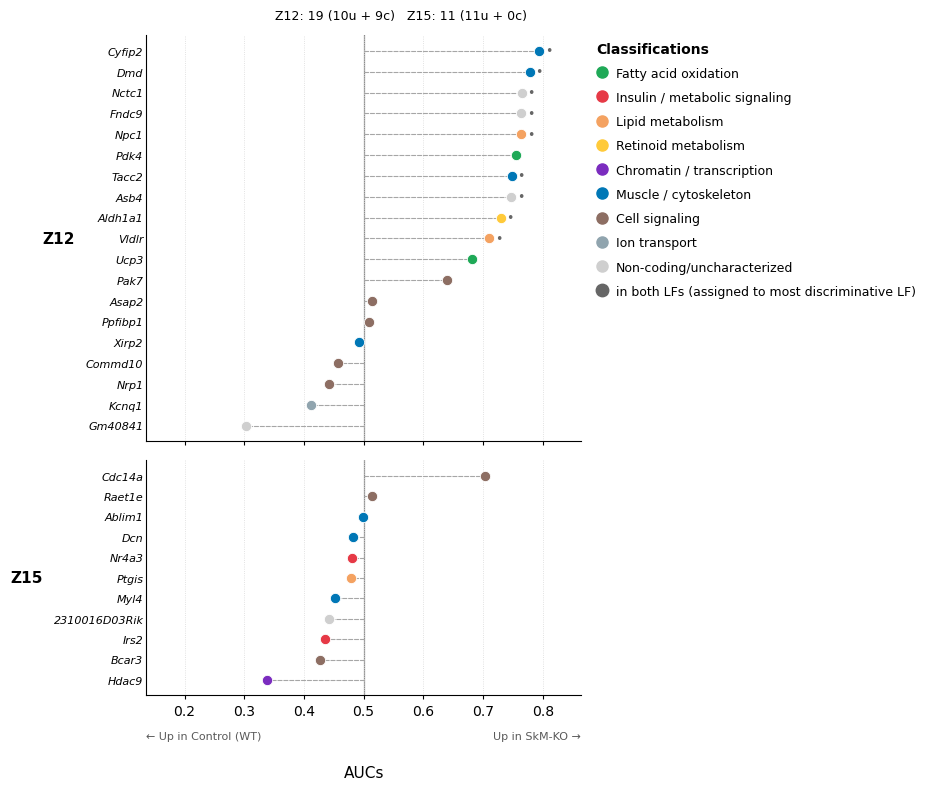

'/ix/djishnu/Akanksha/datasets/ERCC1_KO/figures/Z12_Z15_female_AUCs_stacked_dotplot.svg'

In [ ]:
pgl.plot_lfs_dotplot_stacked(
    lf_specs=[
        {"df": Z12_df, "pathway_map": pathway_map_unified,
         "palette": palette_unified, "latent_factor": "Z12"},
        {"df": Z15_df, "pathway_map": pathway_map_unified,
         "palette": palette_unified, "latent_factor": "Z15"},
    ],
    figures_dir=figures_dir,
    sex="female",
    metric="AUCs",
    max_genes=30,
    # AUC is directional around 0.5: center the axis so each gene diverges
    # to the side (label) it predicts; |AUC - 0.5| is its predictive
    # capacity in that direction. Convention matches the correlation
    # networks: AUC > 0.5 -> up in SkM-KO (Y=1), < 0.5 -> up in WT (Y=0).
    center=0.5,
    direction_labels=("Up in Control (WT)", "Up in SkM-KO"),
)


### A Loading plots

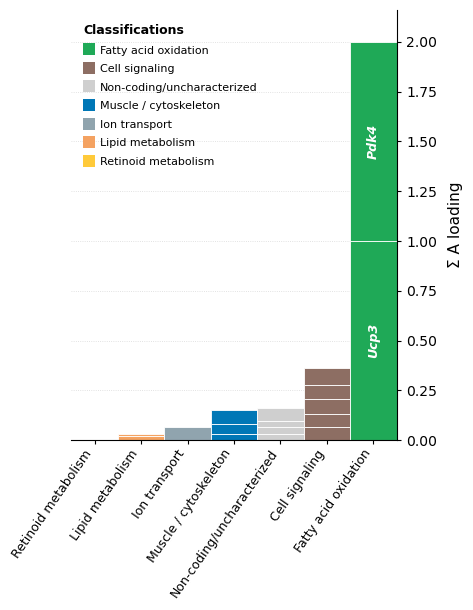

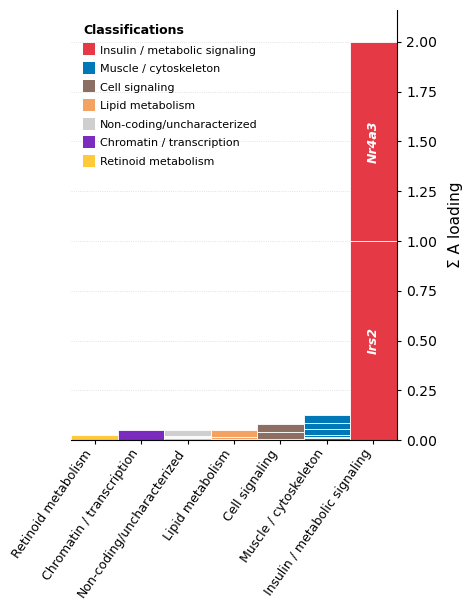

'/ix/djishnu/Akanksha/datasets/ERCC1_KO/figures/Z15_female_Aloading_pathway_bar.svg'

In [9]:
pgl.plot_lf_aloading_pathway_bar(
    df=Z12_df,
    pathway_map=pathway_map_unified,
    palette=palette_unified,
    latent_factor="Z12",
    figures_dir=figures_dir,
    sex="female",
)

pgl.plot_lf_aloading_pathway_bar(
    df=Z15_df,
    pathway_map=pathway_map_unified,
    palette=palette_unified,
    latent_factor="Z15",
    figures_dir=figures_dir,
    sex="female",
)

### Correlation plots per LF

2026-05-28 13:04:52 | [WARNING] Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
2026-05-28 13:04:52 | [WARNING] Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


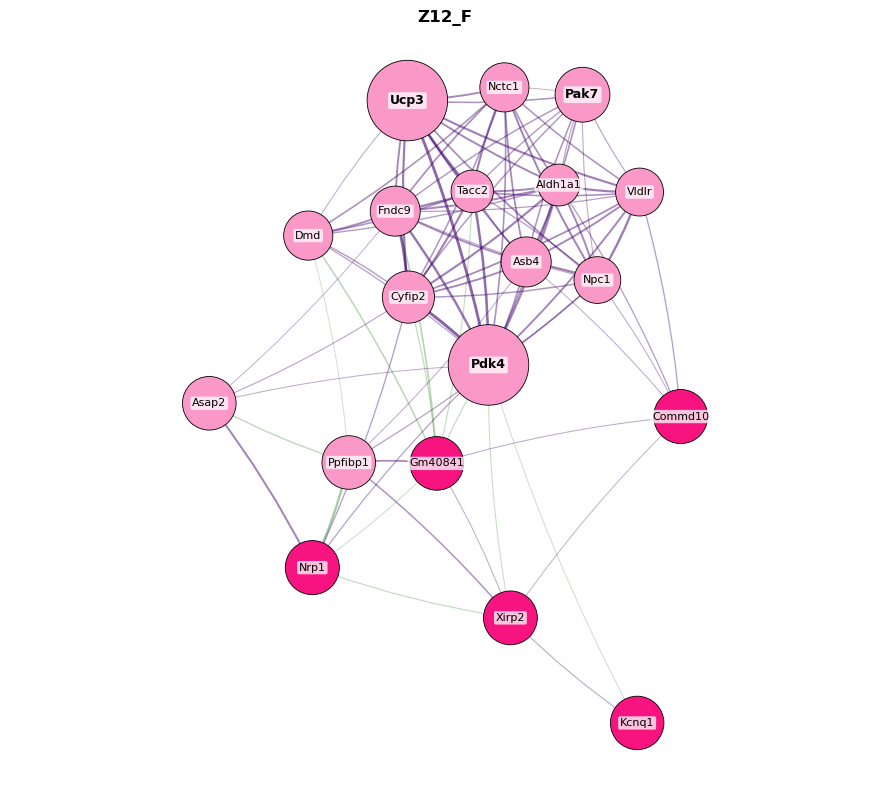

2026-05-28 13:04:52 | [WARNING] Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
2026-05-28 13:04:52 | [WARNING] Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


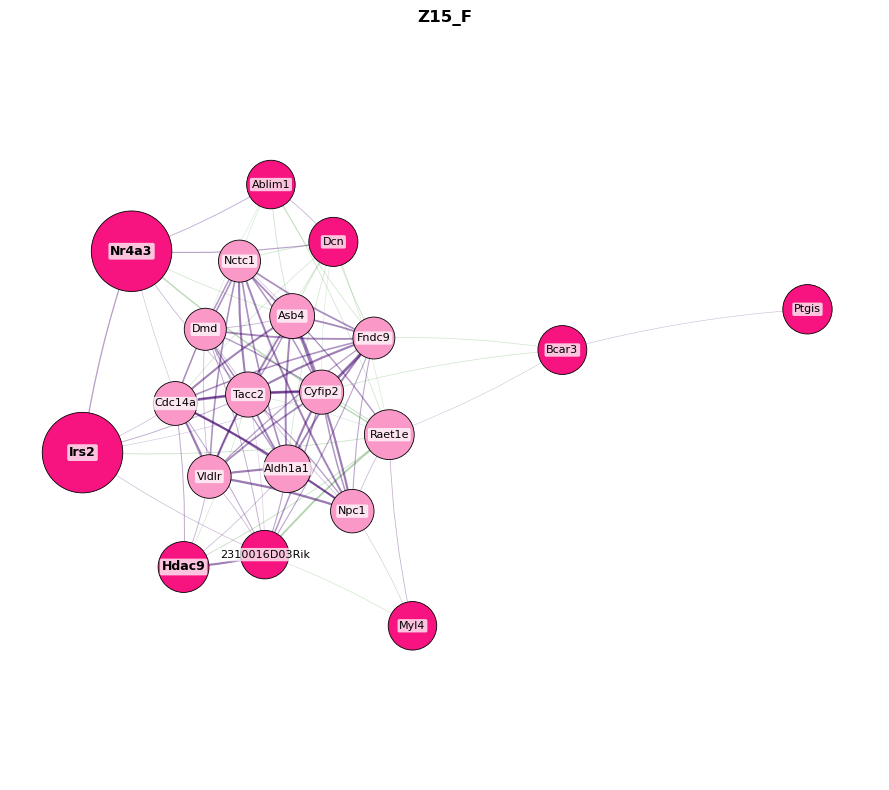

'/ix/djishnu/Akanksha/datasets/ERCC1_KO/figures/correlation_networks/Z15_F.svg'

In [37]:
# SLIDE inputs for the female 0.01_0.1 run (paths from yaml_params.yaml).
x_path = '/ix/djishnu/Akanksha/datasets/ERCC1_KO/metacell/female_fast2b_2x_harmonyv2_X.csv'
y_path = '/ix/djishnu/Akanksha/datasets/ERCC1_KO/metacell/female_fast2b_2x_harmonyv2_Y.csv'

x_df = pd.read_csv(x_path, index_col=0)
x_df.columns = x_df.columns.str.replace(' ', '_', regex=False)
y_vec = pd.read_csv(y_path, index_col=0).iloc[:, 0].values

corr_net_dir = f"{figures_dir}/correlation_networks"

# Node colors come from the SEX_CONDITION_PALETTE defined at the top of the
# notebook, so nodes match the rest of the figures' color story:
#   - high_y_color = up in KO  (case, Y=1)   -> light pink for females
#   - low_y_color  = up in WT  (control, Y=0) -> hot pink for females
female_high = SEX_CONDITION_PALETTE[('F', 'KO')]   # gene UP in SkM-KO
female_low  = SEX_CONDITION_PALETTE[('F', 'WT')]   # gene UP in Control

# Reference-figure look (BCKDHB / BCAT2 metabolic network) -- final
# settings after iterating on real Z12 / Z15 data:
#
# LAYOUT (equispaced spread):
#   weighted_attraction=False -> uniform spring constants, so the layout
#       spreads nodes evenly instead of pulling strongly-correlated
#       pairs on top of each other.
#   repulsion=12.0           -> high k pushes nodes apart; combined with
#       weighted_attraction=False produces a near-ring distribution
#       with hubs central.
#   community_layout=False   -> single spring layout (2 modules per LF
#       made polygon arrangement look stacked vertically).
#
# EDGES (lighter, less crowded):
#   max_edge_width=2.5       -> halved from 4.5 so even the strongest
#       edges don't dominate.
#   max_edge_alpha=0.7       -> drops the strong-edge opacity from 1.0
#       so edges are present but read as a network not a mesh.
#   edge_curvature=0.05      -> subtle bend so crossing edges don't
#       merge visually.
#
# NODE SIZE (smooth gradient via A_loading):
#   size_metric="A_loading"  -> Pdk4+Ucp3 dominate Z12, Nr4a3+Irs2
#       dominate Z15. Without this, Nr4a3 disappears (rank 13/20 by
#       weighted degree); A_loading captures SLIDE-driver hubness.
#   size_power=0.5,
#   node_size_min_factor=0.65, node_size_max_factor=2.4
#       -> ~3.7x area ratio (was ~8x). Heroes still 2x bigger than
#       next tier but no peripheral is a dot.
#
# THRESHOLDS:
#   minimum: 0.25 for Z12 (no isolates), 0.15 for Z15 (absorbs Ptgis)
#   seed=1 (reproducible orientation)
common_kwargs = dict(
    out_dir=corr_net_dir,
    repulsion=12.0,
    iterations=1000,
    layout="spring",
    weighted_attraction=False,
    community_layout=False,
    edge_curvature=0.05,
    figsize=(9, 8),
    node_size=1400,
    node_size_by_degree=True,
    node_size_min_factor=0.65,
    node_size_max_factor=2.4,
    size_metric="A_loading",
    hub_metric="A_loading",
    size_power=0.5,
    font_size=8,
    label_bbox=True,
    hub_label_bold=True,
    hub_quantile=0.85,
    max_edge_width=2.5,
    min_edge_alpha=0.18,
    max_edge_alpha=0.7,
    high_y_color=female_high,
    low_y_color=female_low,
    seed=1,
)

# Quick-tune presets:
#   modules-cluster   = dict(weighted_attraction=True, repulsion=8)
#       -> strongly correlated genes physically cluster (was iter 6 look)
#   bolder-edges      = dict(max_edge_width=4.5, max_edge_alpha=1.0)
#       -> bring back the heavier edges
#   crisp-hubs        = dict(size_power=1.0, node_size_min_factor=0.45,
#                            node_size_max_factor=3.5)
#       -> binary hero/peripheral hierarchy (was iter 5)
#   by-degree         = dict(size_metric=None, hub_metric=None)

# Z12: clean at minimum=0.25 (all 19 genes have at least one edge already).
pgl.plot_lf_correlation_network(
    x=x_df, feature_list=Z12_df, y=y_vec,
    latent_factor="Z12_F", minimum=0.25, **common_kwargs,
)

# Z15: drop to minimum=0.15 so Ptgis stops floating in a corner.
pgl.plot_lf_correlation_network(
    x=x_df, feature_list=Z15_df, y=y_vec,
    latent_factor="Z15_F", minimum=0.15, **common_kwargs,
)
